## 0. Dataset Setup — Automatic UCI Download

The notebook retrieves the **official UCI Human Activity Recognition Using Smartphones** ZIP automatically, so the experiment can be run in Google Colab without manually uploading the dataset.

UCI identifies this as dataset 240 and provides the original `UCI HAR Dataset.zip` file. The dataset contains 10,299 observations and 561 features and is explicitly listed as supporting clustering. 

If the dataset is already present, the download step is skipped.


In [1]:
import os
import zipfile
import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42

# Check for local directory first, then fallback to Colab path
if (Path("UCI HAR Dataset") / "features.txt").exists():
    DATASET_PATH = Path("UCI HAR Dataset")
elif (Path("Assignment 8") / "UCI HAR Dataset" / "features.txt").exists():
    DATASET_PATH = Path("Assignment 8") / "UCI HAR Dataset"
elif (Path("/content") / "UCI HAR Dataset" / "features.txt").exists():
    DATASET_PATH = Path("/content") / "UCI HAR Dataset"
else:
    BASE_DIR = Path(".")
    ZIP_PATH = BASE_DIR / "human_activity_recognition.zip"
    DATASET_PATH = BASE_DIR / "UCI HAR Dataset"
    UCI_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
    if not (DATASET_PATH / "features.txt").exists():
        print("Downloading the official UCI HAR dataset...")
        urllib.request.urlretrieve(UCI_URL, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(BASE_DIR)
        if not (DATASET_PATH / "features.txt").exists():
            nested_zip = BASE_DIR / "UCI HAR Dataset.zip"
            if nested_zip.exists():
                with zipfile.ZipFile(nested_zip, "r") as z:
                    z.extractall(BASE_DIR)

print("DATASET_PATH =", DATASET_PATH)

FIGURES_DIR = Path("figures8")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


DATASET_PATH = Assignment 8\UCI HAR Dataset


## 1. Load Dataset

In [2]:
def load_har_dataset(dataset_path):
    path = Path(dataset_path)

    features = pd.read_csv(path / "features.txt", sep=r"\s+", header=None)
    feature_names = features[1].astype(str).tolist()

    # Ensure unique column names.
    counts = {}
    unique_names = []
    for name in feature_names:
        counts[name] = counts.get(name, 0) + 1
        unique_names.append(name if counts[name] == 1 else f"{name}_{counts[name]}")

    X_train = pd.read_csv(path / "train" / "X_train.txt", sep=r"\s+", header=None)
    X_test = pd.read_csv(path / "test" / "X_test.txt", sep=r"\s+", header=None)
    y_train = pd.read_csv(path / "train" / "y_train.txt", header=None, names=["activity_id"])
    y_test = pd.read_csv(path / "test" / "y_test.txt", header=None, names=["activity_id"])

    activity_labels = pd.read_csv(
        path / "activity_labels.txt",
        sep=r"\s+",
        header=None,
        names=["activity_id", "activity"]
    )

    X = pd.concat([X_train, X_test], ignore_index=True)
    X.columns = unique_names

    y = pd.concat([y_train, y_test], ignore_index=True)
    y = y.merge(activity_labels, on="activity_id", how="left")

    return X, y, activity_labels

X, y, activity_labels = load_har_dataset(DATASET_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(activity_labels)


X shape: (10299, 561)
y shape: (10299, 2)


,activity_id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


## 2. EDA and Preprocessing

Missing values: 0


Duplicate rows: 0

Activity distribution:


activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

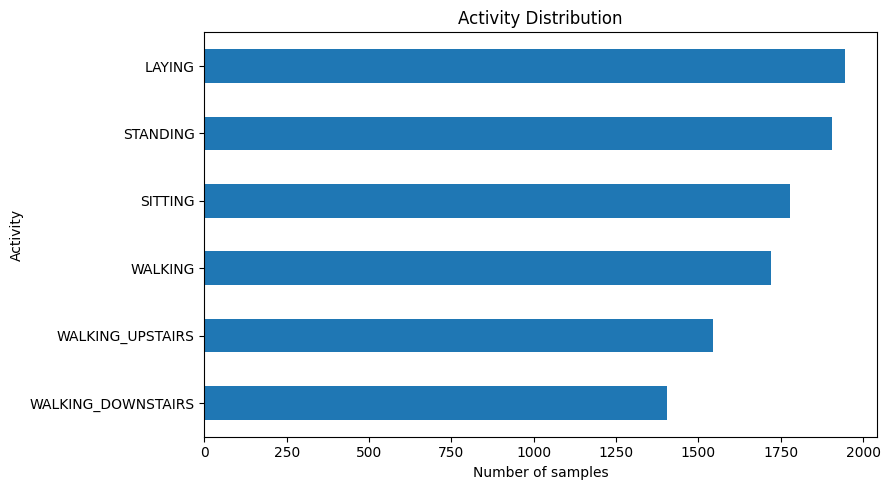

Standardized matrix shape: (10299, 561)


In [3]:
print("Missing values:", X.isna().sum().sum())
print("Duplicate rows:", X.duplicated().sum())
print("\nActivity distribution:")
display(y["activity"].value_counts())
plt.figure(figsize=(9, 5))
y["activity"].value_counts().sort_values().plot(kind="barh")
plt.xlabel("Number of samples")
plt.ylabel("Activity")
plt.title("Activity Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'activity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Standardized matrix shape:", X_scaled.shape)


## 3. PCA — 2D Visualization

PC1 variance: 0.5074
PC2 variance: 0.0624
Total: 0.5698


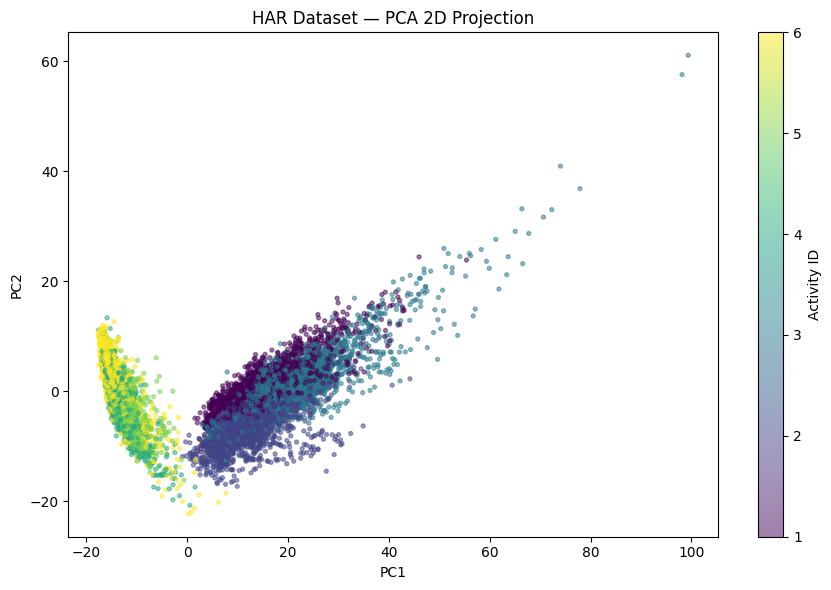

In [4]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print("PC1 variance:", round(pca_2d.explained_variance_ratio_[0], 4))
print("PC2 variance:", round(pca_2d.explained_variance_ratio_[1], 4))
print("Total:", round(pca_2d.explained_variance_ratio_.sum(), 4))
plt.figure(figsize=(9, 6))
s = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                c=y["activity_id"], s=8, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("HAR Dataset — PCA 2D Projection")
plt.colorbar(s, label="Activity ID")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ground_truth_pca2d.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Evaluation Function

In [5]:
def evaluate_clustering(X_data, labels, true_labels=None):
    labels = np.asarray(labels)
    non_noise = labels != -1

    if non_noise.sum() > 1 and len(np.unique(labels[non_noise])) >= 2:
        X_eval = np.asarray(X_data)[non_noise]
        y_eval = labels[non_noise]
        sil = silhouette_score(X_eval, y_eval)
        db = davies_bouldin_score(X_eval, y_eval)
        ch = calinski_harabasz_score(X_eval, y_eval)
    else:
        sil = db = ch = np.nan

    result = {
        "Clusters": len(np.unique(labels[non_noise])),
        "Noise Points": int((labels == -1).sum()),
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    }

    if true_labels is not None:
        result["ARI"] = adjusted_rand_score(true_labels, labels)
        result["NMI"] = normalized_mutual_info_score(true_labels, labels)

    return result

def plot_clusters(X_2d, labels, title):
    plt.figure(figsize=(9, 6))
    s = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=labels, s=8, alpha=0.55)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.colorbar(s, label="Cluster")
    plt.tight_layout()
    plt.show()

## 5. K-Means — Elbow and Silhouette

,k,WCSS,Silhouette
0,2,3.272857e+06,0.393732
1,3,2.921078e+06,0.315484
2,4,2.781602e+06,0.150005
3,5,2.654790e+06,0.128631
4,6,2.577180e+06,0.109895
5,7,2.519774e+06,0.081599
6,8,2.465379e+06,0.074867


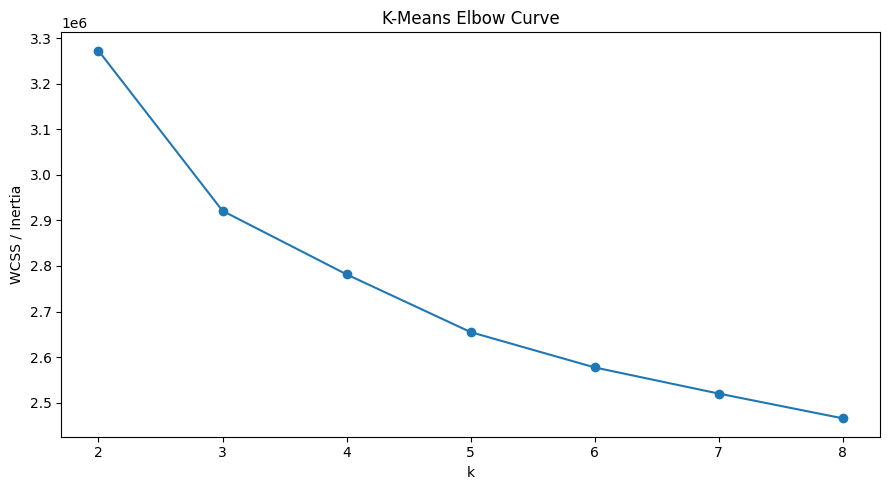

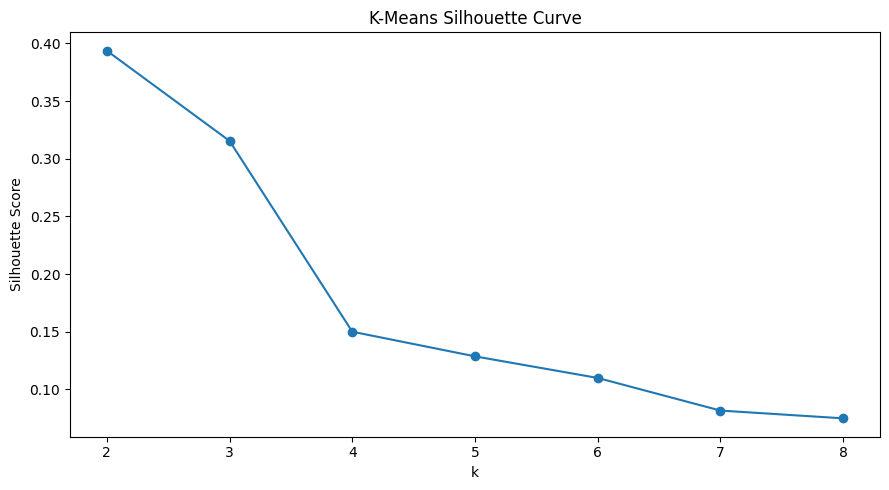

Selected k using maximum Silhouette Score: 2


In [6]:
def kmeans_analysis(X_data, k_values=range(2, 9)):
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        labels = model.fit_predict(X_data)
        rows.append({
            "k": k,
            "WCSS": model.inertia_,
            "Silhouette": silhouette_score(X_data, labels)
        })
    return pd.DataFrame(rows)
kmeans_results = kmeans_analysis(X_scaled)
display(kmeans_results)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(kmeans_results["k"], kmeans_results["WCSS"], marker="o")
ax.set_xlabel("k")
ax.set_ylabel("WCSS / Inertia")
ax.set_title("K-Means Elbow Curve")
ax.set_xticks(kmeans_results["k"])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_elbow_curve.png", dpi=300, bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(kmeans_results["k"], kmeans_results["Silhouette"], marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("K-Means Silhouette Curve")
ax.set_xticks(kmeans_results["k"])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_silhouette_curve.png", dpi=300, bbox_inches="tight")
plt.show()
BEST_K = int(kmeans_results.loc[kmeans_results["Silhouette"].idxmax(), "k"])
print("Selected k using maximum Silhouette Score:", BEST_K)


,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,2,0,0.393732,1.070744,7880.813904,0.329611,0.545464


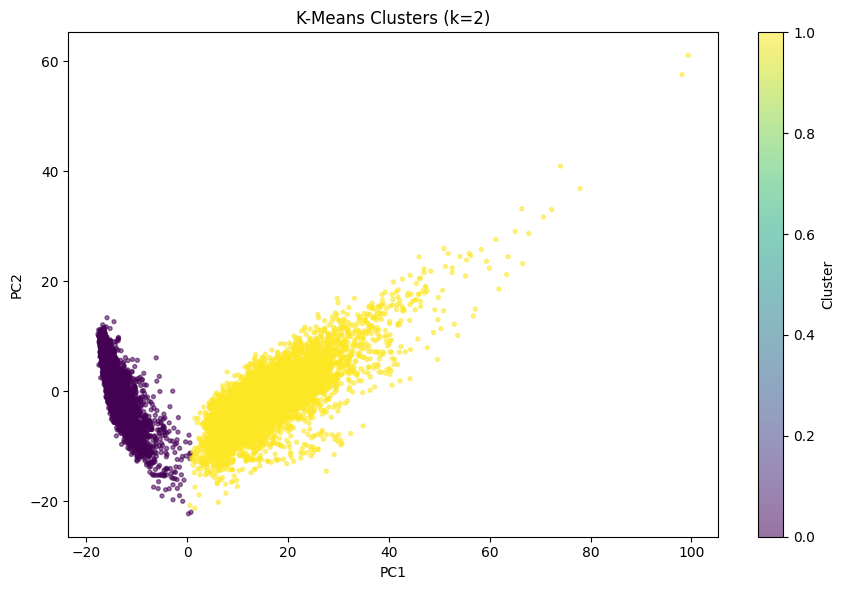

In [7]:
def run_kmeans(X_data, k, true_labels=None):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_data)
    metrics = evaluate_clustering(X_data, labels, true_labels)
    return model, labels, metrics

kmeans_model, kmeans_labels, kmeans_metrics = run_kmeans(
    X_scaled, BEST_K, y["activity_id"].values
)

display(pd.DataFrame([kmeans_metrics]))
plot_clusters(X_pca_2d, kmeans_labels, f"K-Means Clusters (k={BEST_K})")
plt.figure(figsize=(9, 6))
s = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, s=8, alpha=0.55)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clusters (k={BEST_K})')
plt.colorbar(s, label='Cluster')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kmeans_clusters_pca2d.png', dpi=300, bbox_inches='tight')
plt.close()



## 6. DBSCAN

For DBSCAN, a PCA representation retaining 95% variance is used to reduce the computational burden of density calculations. A reproducible stratified sample is used for the expensive DBSCAN/HAC experiments.

In [8]:
pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca_95.shape[1])
print("Variance retained:", round(pca_95.explained_variance_ratio_.sum(), 4))

def stratified_sample_indices(labels, max_samples=2500):
    labels = np.asarray(labels)
    if len(labels) <= max_samples:
        return np.arange(len(labels))

    rng = np.random.default_rng(RANDOM_STATE)
    selected = []
    classes = np.unique(labels)
    per_class = max_samples // len(classes)

    for c in classes:
        idx = np.where(labels == c)[0]
        selected.extend(rng.choice(idx, min(per_class, len(idx)), replace=False))

    remaining = max_samples - len(selected)
    if remaining > 0:
        available = np.setdiff1d(np.arange(len(labels)), selected)
        selected.extend(rng.choice(available, remaining, replace=False))

    return np.array(sorted(selected))

sample_idx = stratified_sample_indices(y["activity_id"].values, 2500)
X_cluster = X_pca_95[sample_idx]
y_cluster = y["activity_id"].values[sample_idx]
X_cluster_2d = X_pca_2d[sample_idx]

print("DBSCAN/HAC sample:", X_cluster.shape)

Original dimensions: 561
PCA dimensions: 104
Variance retained: 0.9505
DBSCAN/HAC sample: (2500, 104)


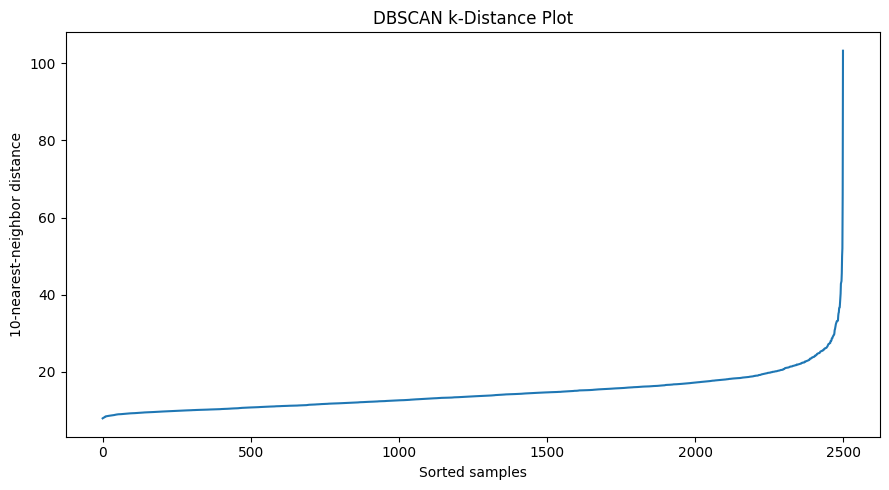

,eps,min_samples,clusters,noise_ratio,silhouette
0,0.5,5,0,1.0,NaN
1,0.5,10,0,1.0,NaN
2,0.5,15,0,1.0,NaN
3,1.0,5,0,1.0,NaN
4,1.0,10,0,1.0,NaN
5,1.0,15,0,1.0,NaN
6,1.5,5,0,1.0,NaN
7,1.5,10,0,1.0,NaN
8,1.5,15,0,1.0,NaN
9,2.0,5,0,1.0,NaN


In [9]:
# k-distance plot helps inspect a reasonable eps range.
k = 10
nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
nn.fit(X_cluster)
distances, _ = nn.kneighbors(X_cluster)
k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.xlabel("Sorted samples")
plt.ylabel(f"{k}-nearest-neighbor distance")
plt.title("DBSCAN k-Distance Plot")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dbscan_k_distance.png', dpi=300, bbox_inches='tight')
plt.show()
def dbscan_grid_search(X_data, eps_values, min_samples_values):
    rows = []
    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
            labels = model.fit_predict(X_data)
            mask = labels != -1
            clusters = len(np.unique(labels[mask])) if mask.any() else 0
            noise_ratio = (labels == -1).mean()
            sil = np.nan
            if mask.sum() > 1 and clusters >= 2:
                sil = silhouette_score(X_data[mask], labels[mask])
            rows.append({
                "eps": eps,
                "min_samples": min_samples,
                "clusters": clusters,
                "noise_ratio": noise_ratio,
                "silhouette": sil
            })
    return pd.DataFrame(rows)
dbscan_results = dbscan_grid_search(
    X_cluster,
    eps_values=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
    min_samples_values=[5, 10, 15]
)
display(dbscan_results.sort_values("silhouette", ascending=False).head(10))


Selected eps: 2.0
Selected min_samples: 10


,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,0,2500,NaN,NaN,NaN,0.0,0.0


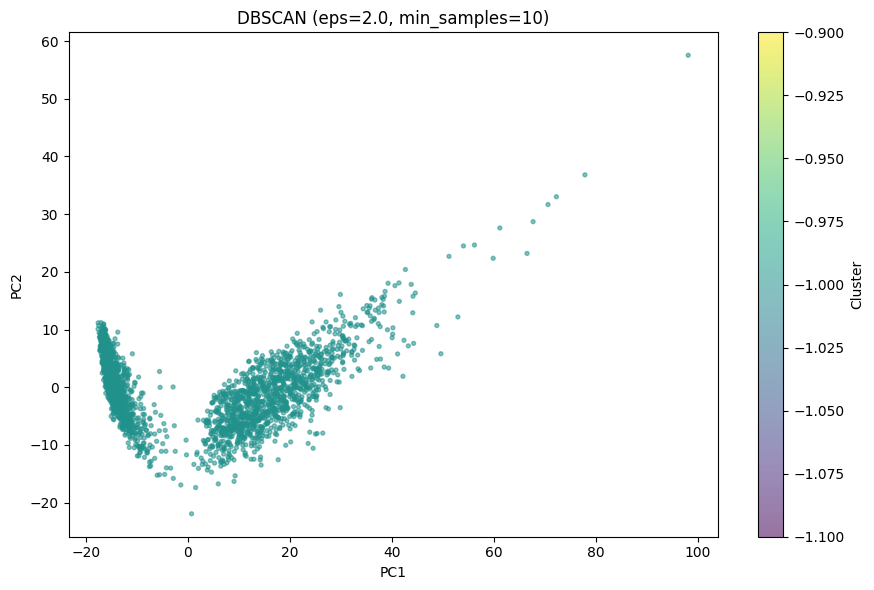

In [10]:
valid = dbscan_results.dropna(subset=["silhouette"])

if len(valid):
    best = valid.sort_values(
        ["silhouette", "noise_ratio"],
        ascending=[False, True]
    ).iloc[0]
    DB_EPS = float(best["eps"])
    DB_MIN_SAMPLES = int(best["min_samples"])
else:
    DB_EPS = 2.0
    DB_MIN_SAMPLES = 10

print("Selected eps:", DB_EPS)
print("Selected min_samples:", DB_MIN_SAMPLES)

def run_dbscan(X_data, eps, min_samples, true_labels=None):
    model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = model.fit_predict(X_data)
    metrics = evaluate_clustering(X_data, labels, true_labels)
    return model, labels, metrics

dbscan_model, dbscan_labels, dbscan_metrics = run_dbscan(
    X_cluster, DB_EPS, DB_MIN_SAMPLES, y_cluster
)

display(pd.DataFrame([dbscan_metrics]))
plot_clusters(
    X_cluster_2d, dbscan_labels,
    f"DBSCAN (eps={DB_EPS}, min_samples={DB_MIN_SAMPLES})"
)
plt.figure(figsize=(9, 6))
s = plt.scatter(X_cluster_2d[:, 0], X_cluster_2d[:, 1], c=dbscan_labels, s=8, alpha=0.55)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN (eps={DB_EPS}, min_samples={DB_MIN_SAMPLES})')
plt.colorbar(s, label='Cluster')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dbscan_clusters_pca2d.png', dpi=300, bbox_inches='tight')
plt.close()



## 7. Hierarchical Agglomerative Clustering

,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,2,0,0.404504,1.00938,2061.651708,0.332889,0.557886


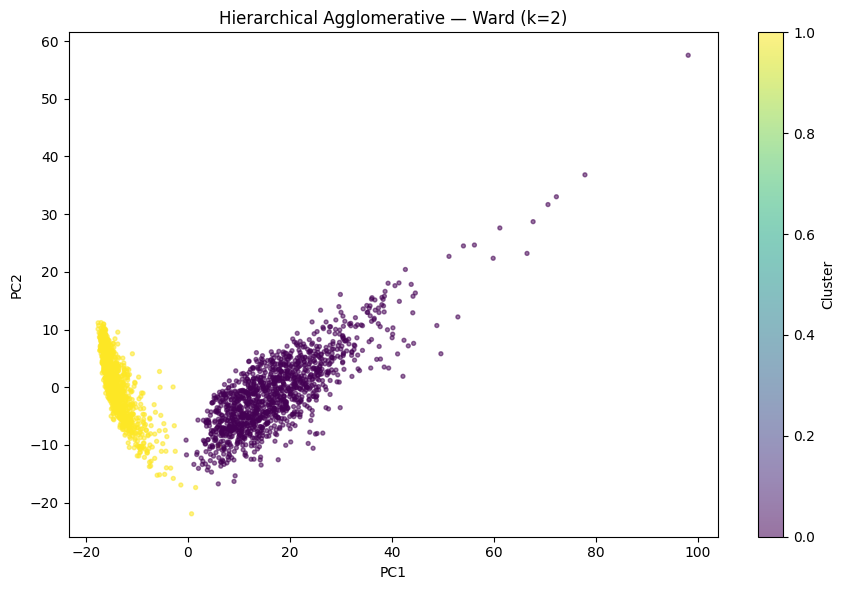

In [11]:
def run_hierarchical(X_data, n_clusters, linkage_method="ward", true_labels=None):
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage_method
    )
    labels = model.fit_predict(X_data)
    metrics = evaluate_clustering(X_data, labels, true_labels)
    return model, labels, metrics

hac_model, hac_labels, hac_metrics = run_hierarchical(
    X_cluster, BEST_K, "ward", y_cluster
)

display(pd.DataFrame([hac_metrics]))
plot_clusters(
    X_cluster_2d, hac_labels,
    f"Hierarchical Agglomerative — Ward (k={BEST_K})"
)
plt.figure(figsize=(9, 6))
s = plt.scatter(X_cluster_2d[:, 0], X_cluster_2d[:, 1], c=hac_labels, s=8, alpha=0.55)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Hierarchical Agglomerative - Ward (k={BEST_K})')
plt.colorbar(s, label='Cluster')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hac_ward_clusters_pca2d.png', dpi=300, bbox_inches='tight')
plt.close()



In [12]:
# Required Ward model + linkage comparison requested by the observation questions.
linkage_rows = []

for method in ["single", "complete", "ward"]:
    model, labels, metrics = run_hierarchical(
        X_cluster, BEST_K, method, y_cluster
    )
    row = {"Linkage": method}
    row.update(metrics)
    linkage_rows.append(row)

linkage_results = pd.DataFrame(linkage_rows)
display(linkage_results)

,Linkage,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,single,2,0,0.790957,0.149718,40.283729,5.145831e-07,0.000800
1,complete,2,0,0.645314,0.677146,125.777207,6.316865e-05,0.007937
2,ward,2,0,0.404504,1.009380,2061.651708,3.328893e-01,0.557886


### Dendrogram — Ward Linkage

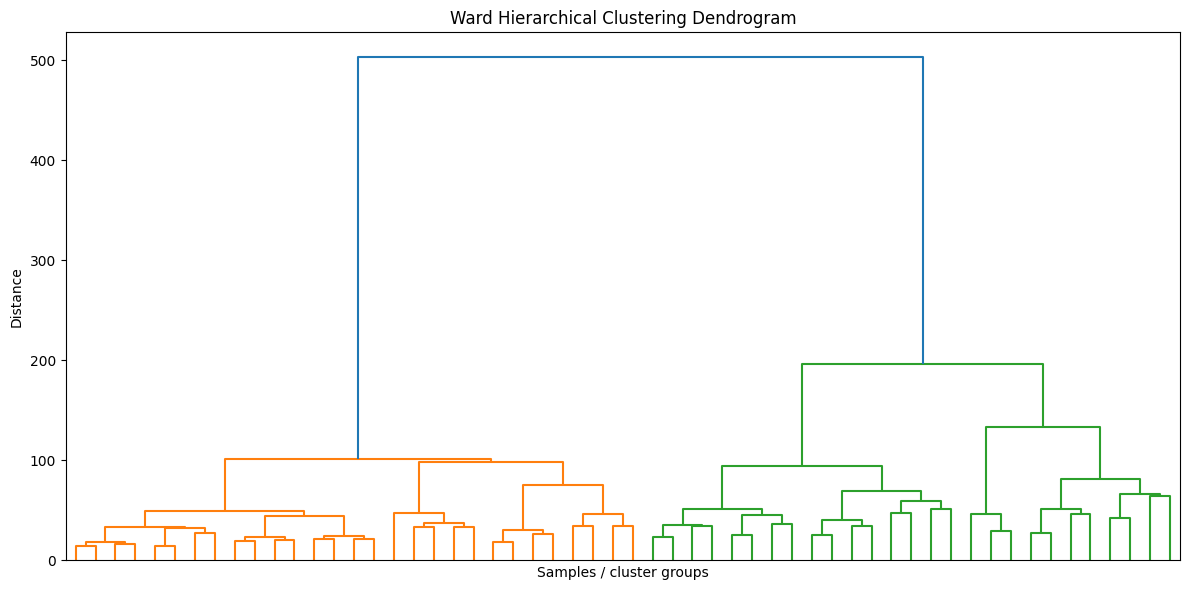

In [13]:
# Dendrogram is shown on a smaller reproducible subset for readability/runtime.
d_idx = stratified_sample_indices(y_cluster, 500)
Z = linkage(X_cluster[d_idx], method="ward")
plt.figure(figsize=(12, 6))
dendrogram(Z, no_labels=True, truncate_mode="level", p=5)
plt.xlabel("Samples / cluster groups")
plt.ylabel("Distance")
plt.title("Ward Hierarchical Clustering Dendrogram")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hac_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Final Comparison

,Algorithm,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means,2,0,0.393732,1.070744,7880.813904,0.329611,0.545464
1,DBSCAN,0,2500,NaN,NaN,NaN,0.000000,0.000000
2,Hierarchical (Ward),2,0,0.404504,1.009380,2061.651708,0.332889,0.557886


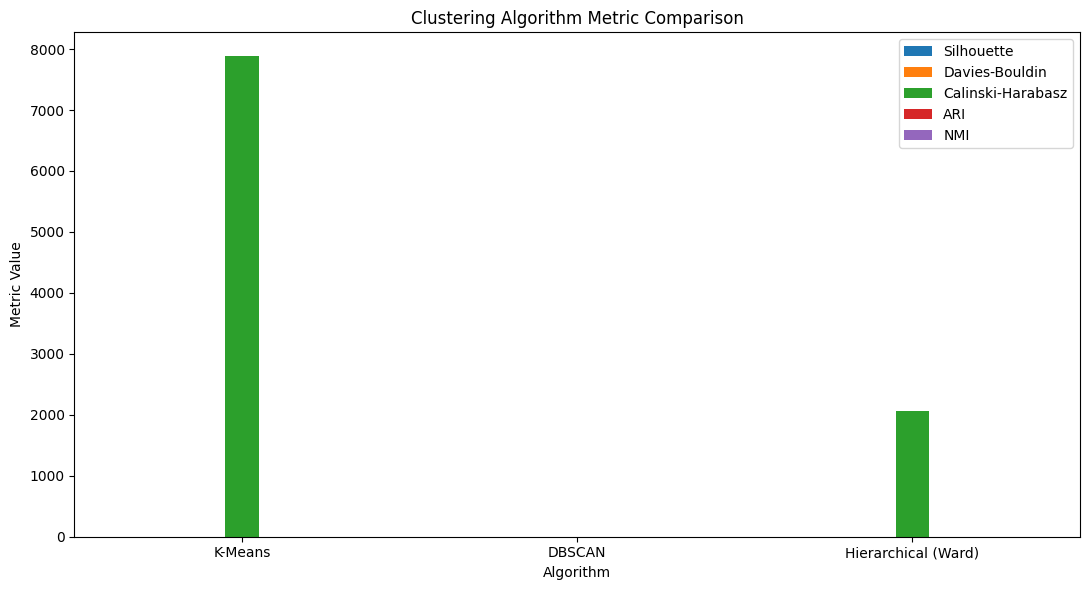

In [14]:
comparison = pd.DataFrame([
    {"Algorithm": "K-Means", **kmeans_metrics},
    {"Algorithm": "DBSCAN", **dbscan_metrics},
    {"Algorithm": "Hierarchical (Ward)", **hac_metrics}
])
display(comparison)
metrics_to_plot = [
    "Silhouette", "Davies-Bouldin",
    "Calinski-Harabasz", "ARI", "NMI"
]
ax = comparison.set_index("Algorithm")[metrics_to_plot].plot(
    kind="bar", figsize=(11, 6), rot=0
)
ax.set_title("Clustering Algorithm Metric Comparison")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Metric Value")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
def cluster_sizes(labels):
    return pd.Series(labels, name="Cluster").value_counts().sort_index().rename("Samples").to_frame()

print("K-Means cluster sizes")
display(cluster_sizes(kmeans_labels))

print("DBSCAN cluster sizes (-1 = noise)")
display(cluster_sizes(dbscan_labels))

print("Ward HAC cluster sizes")
display(cluster_sizes(hac_labels))

K-Means cluster sizes


,Samples
Cluster,
0,5620
1,4679


DBSCAN cluster sizes (-1 = noise)


,Samples
Cluster,
-1,2500


Ward HAC cluster sizes


,Samples
Cluster,
0,1248
1,1252


## 9. Observation Questions

Use the generated results rather than assuming an outcome beforehand.

1. **Which algorithm produced the most meaningful clusters?**  
   Discuss the PCA plots together with Silhouette, Davies–Bouldin, Calinski–Harabasz, ARI and NMI.

2. **How sensitive was K-Means to the choice of k?**  
   Discuss the WCSS elbow and Silhouette curve for `k = 2,...,8`.

3. **Did DBSCAN detect noise or small clusters effectively?**  
   Refer to the number of noise points, noise ratio, number of clusters and PCA plot.

4. **How does linkage choice affect hierarchical clustering?**  
   Compare Single, Complete and Ward using the linkage table and cluster plots/metrics.

5. **Which internal metric best matched visual intuition?**  
   Compare the visual separation with Silhouette, Davies–Bouldin and Calinski–Harabasz.

**Important:** the true activity labels are not used to fit the clustering models. ARI and NMI are external evaluation measures only.

## Dataset Source

The dataset is retrieved from the official **UCI Machine Learning Repository**, dataset 240: *Human Activity Recognition Using Smartphones*. UCI describes it as a clustering-capable dataset with 10,299 instances and 561 features.

Reference: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones
